# 04 — What do the segmentation-stain images add to the transcriptome?

Within each cell type (18S-segmented cells; ≥ 500 cells, ≥ 5 animals; max 30,000 cells per type),
cross-validated **by animal** (5-fold GroupKFold on `sample_name`):

1. **Image ← transcriptome.** For each image feature: R² from technical covariates alone (section, spinal level,
   log transcripts, log area, log edge distance), R² from covariates + 50 transcriptome PCs, and the difference
   (what the transcriptome adds). `1 − R²_full` = image signal not explained here.
2. **Transcriptome ← image.** Transcriptome PCs and individual genes predicted from covariates ± image features.
3. **Is the unexplained part signal or noise?** Spatial coherence of residuals among same-type neighbours.
4. **Does the unexplained part carry disease information?** Per-feature residual lesion-vs-physiological shift
   (per animal), lesion classification with transcriptome vs transcriptome + image, residual clusters.

Caveats carried from earlier phases: ATP1A1 channel has no detectable CD45; 18S drew these masks, so 18S
*distribution* features (radial, rim) are partly by construction.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial import cKDTree
from scipy.stats import wilcoxon
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth

plotting.style()
SRC = "notebooks/04_orthogonality.ipynb"
OUT = ROOT / "results" / "04_orthogonality"
OUT.mkdir(parents=True, exist_ok=True)
RES = ROOT / "data" / "residuals"
RES.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
MIN_CELLS, MIN_ANIMALS, MAX_CELLS = 500, 5, 30000
rng = np.random.default_rng(0)


def bh(p):
    """Benjamini–Hochberg q-values."""
    p = np.asarray(p, float)
    o = np.argsort(p)
    q = p[o] * len(p) / np.arange(1, len(p) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[o] = np.minimum(q, 1)
    return out

In [2]:
fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa["lesion"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys"] = fa.Curated_niche_state.astype(str) == "Physiological"
fa["lesion_dist_um"] = orth.lesion_distance(fa, fa.lesion.values)
for ch in CH:   # raw-ratio membrane/context features (scale- and background-free)
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])
f = fa[(fa.segmentation_method == "Segmented by interior stain (18S)")
       & ~fa.Anno_L1_curated.isin(["Doublet", "T_B_doublet"])].copy()

FEATS = []
for ch in CH:
    FEATS += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    FEATS += [f"{ch}_radial_b{k}" for k in range(5)]
    FEATS += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    FEATS += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
FEATS += [c for c in f.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset"]
FAM = data.feature_families(FEATS).reindex(FEATS).fillna("intensity: rim/ring ratio")
FAM[[c for c in FEATS if c.endswith("_rim_over_ring")]] = "membrane ratio"
CHAN = pd.Series({c: (c.split("_")[0] if c.split("_")[0] in CH else "morph") for c in FEATS})

n_by = f.groupby("Anno_L1_curated", observed=True).agg(n=("section_id", "size"), animals=("sample_name", "nunique"))
TYPES = n_by[(n_by.n >= MIN_CELLS) & (n_by.animals >= MIN_ANIMALS)].sort_values("n", ascending=False).index.tolist()
print(len(FEATS), "image features;", len(TYPES), "cell types:", TYPES)

105 image features; 14 cell types: ['Oligodendrocyte', 'Myeloid', 'Neuron', 'Fibroblast', 'Astrocyte', 'Endothelial', 'Schwann cell', 'DC', 'T cell', 'OPC', 'VSMC', 'B cell', 'Ependymal cell', 'NK/DC']


In [3]:
cfg = data.load_config()
adata = ad.read_h5ad(ROOT / cfg["annotation"]["h5ad"])
gene_names = adata.var_names.values

## Fit per cell type (results cached in `data/residuals/`)

In [4]:
results = {}
for t in TYPES:
    cache = RES / f"{t.replace('/', '_').replace(' ', '_')}.pkl"
    if cache.exists():
        results[t] = pd.read_pickle(cache)
        continue
    d = f[f.Anno_L1_curated == t]
    if len(d) > MAX_CELLS:
        d = d.loc[rng.choice(d.index.values, MAX_CELLS, replace=False)]
    feats = [c for c in FEATS if d[c].isna().mean() < 0.05]
    X = adata[d.index].X
    Xln = orth.lognorm(X)
    det = np.asarray((X > 0).mean(0)).ravel()
    var = np.asarray(Xln.power(2).mean(0)).ravel() - np.asarray(Xln.mean(0)).ravel() ** 2
    genes = np.where(det >= 0.05)[0]
    genes = genes[np.argsort(-var[genes])[:500]]
    r = orth.run_celltype(d, X, feats, genes=genes)
    r["reverse_genes"].index = gene_names[r["reverse_genes"].index]
    r["n"] = len(d)
    pd.to_pickle(r, cache)
    results[t] = r
    print(f"{t}: n={len(d)}, median R²_cov={r['r2']['cov'].median():.3f}, "
          f"median ΔR²_tx={r['r2']['tx_unique'].median():.3f}", flush=True)

Oligodendrocyte: n=30000, median R²_cov=0.048, median ΔR²_tx=0.090


Myeloid: n=30000, median R²_cov=0.055, median ΔR²_tx=0.105


Neuron: n=30000, median R²_cov=0.035, median ΔR²_tx=0.072


Fibroblast: n=30000, median R²_cov=0.042, median ΔR²_tx=0.068


Astrocyte: n=30000, median R²_cov=0.081, median ΔR²_tx=0.071


...

OPC: n=14242, median R²_cov=0.048, median ΔR²_tx=0.067


VSMC: n=9328, median R²_cov=0.037, median ΔR²_tx=0.091


B cell: n=4548, median R²_cov=0.053, median ΔR²_tx=0.067


Ependymal cell: n=3007, median R²_cov=0.019, median ΔR²_tx=0.064


NK/DC: n=2046, median R²_cov=0.068, median ΔR²_tx=0.056


## 1. How much of each image feature does the transcriptome explain?

In [5]:
r2 = pd.concat({t: r["r2"] for t, r in results.items()}, names=["cell_type", "feature"]).reset_index()
r2["family"] = r2.feature.map(FAM)
r2["channel"] = r2.feature.map(CHAN)
r2.to_csv(OUT / "r2_image_from_transcriptome.csv", index=False)
summ = r2.groupby("cell_type")[["cov", "full", "tx_unique"]].median().loc[TYPES]
summ["unexplained"] = 1 - summ.full
summ.round(3)

,cov,full,tx_unique,unexplained
cell_type,,,,
Oligodendrocyte,0.048,0.152,0.090,0.848
Myeloid,0.055,0.163,0.105,0.837
Neuron,0.035,0.127,0.072,0.873
Fibroblast,0.042,0.123,0.068,0.877
Astrocyte,0.081,0.177,0.071,0.823
Endothelial,0.063,0.156,0.075,0.844
Schwann cell,0.029,0.112,0.068,0.888
DC,0.048,0.165,0.080,0.835
T cell,0.052,0.171,0.091,0.829


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/04_orthogonality/r2_heatmaps.png')

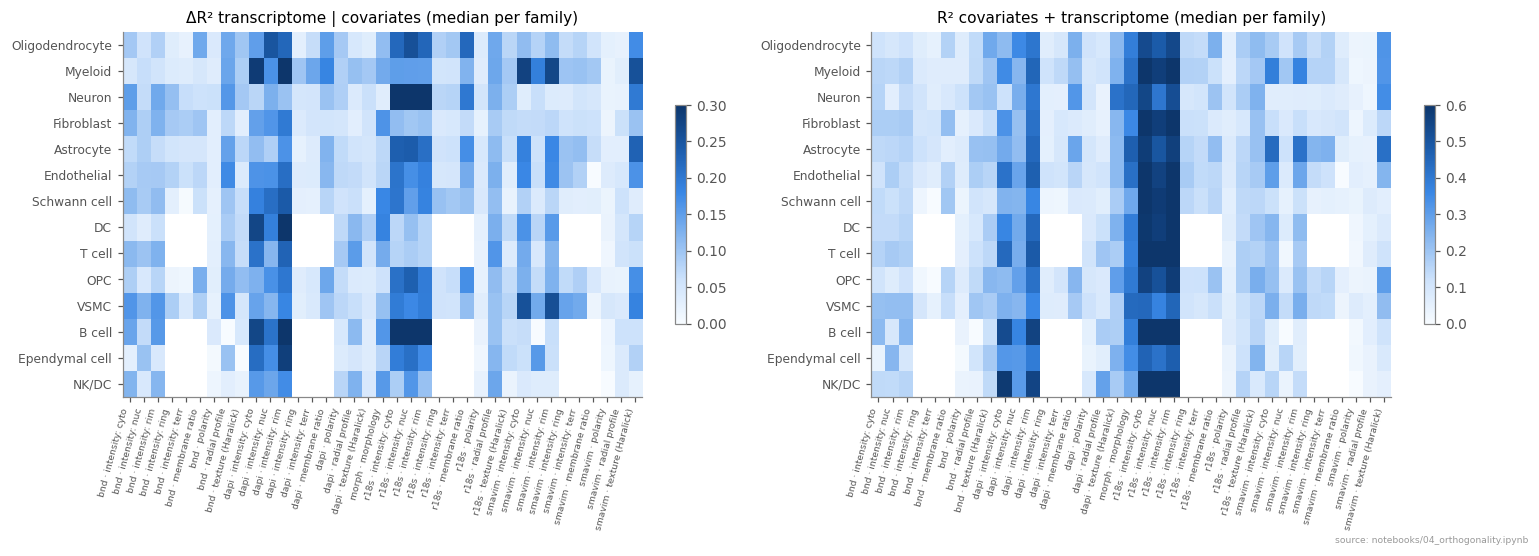

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, val, title, vmax in ((axs[0], "tx_unique", "ΔR² transcriptome | covariates (median per family)", 0.3),
                             (axs[1], "full", "R² covariates + transcriptome (median per family)", 0.6)):
    piv = r2.pivot_table(index="cell_type", columns=["channel", "family"], values=val, aggfunc="median").loc[TYPES]
    im = ax.imshow(piv.values, cmap=plotting.SEQ, vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(piv.shape[1]), [f"{a} · {b}" for a, b in piv.columns], rotation=75, ha="right", fontsize=6)
    ax.set_yticks(range(len(TYPES)), TYPES, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.6)
fig.tight_layout()
plotting.save_fig(fig, "r2_heatmaps", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/04_orthogonality/r2_cov_vs_full.png')

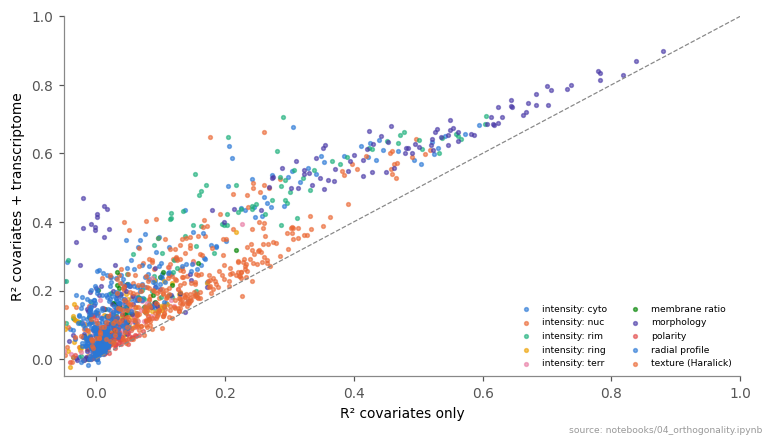

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for k, (fam_, g) in enumerate(r2.groupby("family")):
    ax.scatter(g["cov"], g["full"], s=6, alpha=0.6, color=plotting.CATEGORICAL[k % 8], label=fam_)
ax.plot([0, 1], [0, 1], color="#888888", lw=0.8, ls="--")
ax.set(xlabel="R² covariates only", ylabel="R² covariates + transcriptome", xlim=(-0.05, 1), ylim=(-0.05, 1))
ax.legend(fontsize=6, ncol=2, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "r2_cov_vs_full", OUT, SRC)

Features the transcriptome explains *most* (largest ΔR²), per cell type — these are the image readouts that
largely re-measure transcriptional state:

In [8]:
top_tx = r2.sort_values("tx_unique", ascending=False).groupby("cell_type").head(5)
top_tx[["cell_type", "feature", "cov", "full", "tx_unique"]].round(3).set_index("cell_type").loc[TYPES]

,feature,cov,full,tx_unique
cell_type,,,,
Oligodendrocyte,morph_nuc_cell_ratio,-0.019,0.384,0.384
Oligodendrocyte,r18s_nuc_mean,0.212,0.483,0.271
Oligodendrocyte,dapi_nuc_mean,0.096,0.353,0.257
Oligodendrocyte,r18s_cyto_mean,0.304,0.549,0.244
Oligodendrocyte,r18s_nuc_p90,0.235,0.478,0.244
...,...,...,...,...
NK/DC,morph_nuc_cell_ratio,-0.024,0.273,0.273
NK/DC,r18s_radial_b4,0.001,0.258,0.257
NK/DC,morph_cell_area_um2,0.425,0.666,0.241


## 2. Reverse: how much of the transcriptome do the images predict?

,gene,cov,full,img_unique
cell_type,,,,
Oligodendrocyte,Snap25,0.058,0.357,0.299
Oligodendrocyte,Gfap,0.025,0.301,0.276
Oligodendrocyte,Klk6,0.053,0.303,0.250
Oligodendrocyte,Eno2,0.031,0.268,0.237
Oligodendrocyte,Sncb,0.064,0.300,0.237
...,...,...,...,...
NK/DC,Klrk1,-5.394,0.169,0.169
NK/DC,Cd74,0.003,0.172,0.169
NK/DC,H2-D1,0.138,0.299,0.161


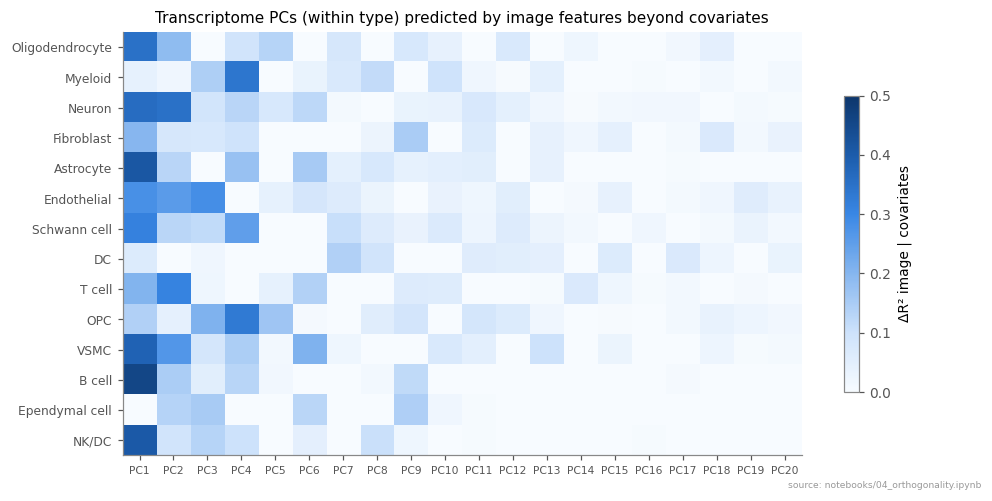

In [9]:
rev = pd.concat({t: r["reverse_pcs"] for t, r in results.items()}, names=["cell_type", "pc"]).reset_index()
rev.to_csv(OUT / "r2_transcriptome_pcs_from_image.csv", index=False)
pv = rev.pivot(index="cell_type", columns="pc", values="img_unique").loc[TYPES][[f"PC{i}" for i in range(1, 21)]]
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(pv.values, cmap=plotting.SEQ, vmin=0, vmax=0.5, aspect="auto")
ax.set_xticks(range(20), pv.columns, fontsize=7); ax.set_yticks(range(len(TYPES)), TYPES, fontsize=8)
fig.colorbar(im, ax=ax, label="ΔR² image | covariates", shrink=0.7)
ax.set_title("Transcriptome PCs (within type) predicted by image features beyond covariates")
fig.tight_layout()
plotting.save_fig(fig, "reverse_pcs", OUT, SRC)

genes_tab = pd.concat({t: r["reverse_genes"] for t, r in results.items()}, names=["cell_type", "gene"]).reset_index()
genes_tab.to_csv(OUT / "r2_genes_from_image.csv", index=False)
top_g = genes_tab.sort_values("img_unique", ascending=False).groupby("cell_type").head(8)
top_g.round(3).set_index("cell_type").loc[TYPES]

## 3. Is the unexplained image signal structured or noise?
Spatial coherence: correlation between a cell's residual and the mean residual of its 10 nearest same-type
neighbours in the same section. Noise → ≈ 0. Tissue state (or local technical artefact) → > 0.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/04_orthogonality/residual_spatial_coherence.png')

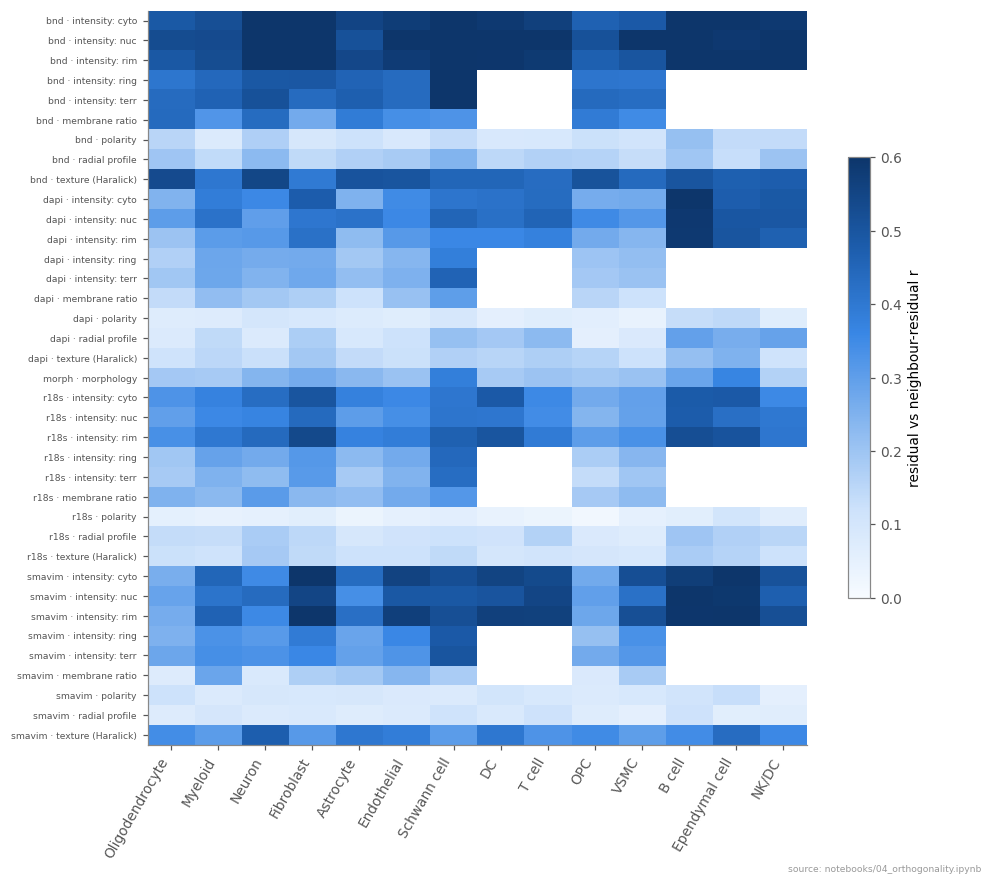

In [10]:
coh = {}
for t, r in results.items():
    res = r["residuals"]
    meta = f.loc[res.index, ["section_id", "x_centroid", "y_centroid"]]
    nb_mean = np.full(res.shape, np.nan)
    for _, idx in meta.groupby("section_id", observed=True).indices.items():
        if len(idx) < 30:
            continue
        xy = meta.iloc[idx][["x_centroid", "y_centroid"]].values
        _, nn = cKDTree(xy).query(xy, k=11)
        nb_mean[idx] = res.values[idx][nn[:, 1:]].mean(1)
    ok = np.isfinite(nb_mean[:, 0])
    coh[t] = pd.Series([np.corrcoef(res.values[ok, j], nb_mean[ok, j])[0, 1] for j in range(res.shape[1])],
                       index=res.columns)
coh = pd.DataFrame(coh)
coh.to_csv(OUT / "residual_spatial_coherence.csv")
coh_f = coh.groupby(coh.index.map(CHAN) + " · " + coh.index.map(FAM)).median()[TYPES]
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(coh_f.values, cmap=plotting.SEQ, vmin=0, vmax=0.6, aspect="auto")
ax.set_yticks(range(len(coh_f)), coh_f.index, fontsize=6); ax.set_xticks(range(len(TYPES)), TYPES, rotation=60, ha="right")
fig.colorbar(im, ax=ax, label="residual vs neighbour-residual r", shrink=0.6)
fig.tight_layout()
plotting.save_fig(fig, "residual_spatial_coherence", OUT, SRC)

## 4a. Does the unexplained image signal differ between lesion and physiological niches?
Per animal: mean residual in lesion-niche cells − mean residual in physiological-niche cells (both ≥ 20 cells);
Wilcoxon signed-rank across animals; BH over all type × feature tests. Effect in residual SD units.

In [11]:
rows = []
for t, r in results.items():
    res = r["residuals"]
    m = f.loc[res.index, ["sample_name", "lesion", "phys"]]
    for an, g in m.groupby("sample_name", observed=True):
        L, P = g.index[g.lesion], g.index[g.phys]
        if len(L) >= 20 and len(P) >= 20:
            diff = res.loc[L].mean() - res.loc[P].mean()
            rows.append(pd.DataFrame({"cell_type": t, "animal": an, "feature": diff.index, "diff": diff.values}))
dl = pd.concat(rows)
tests = []
for (t, feat), g in dl.groupby(["cell_type", "feature"]):
    if len(g) >= 5:
        tests.append(dict(cell_type=t, feature=feat, n_animals=len(g), median_diff=g["diff"].median(),
                          frac_pos=(g["diff"] > 0).mean(), p=wilcoxon(g["diff"]).pvalue))
lt = pd.DataFrame(tests)
lt["q"] = bh(lt.p)
lt["family"] = lt.feature.map(FAM)
lt["coherence"] = [coh.loc[ft, ct] for ct, ft in zip(lt.cell_type, lt.feature)]
lt.to_csv(OUT / "residual_lesion_shift.csv", index=False)
print(f"{(lt.q < 0.05).sum()} / {len(lt)} type × feature residuals shift with lesion (q < 0.05)")
lt[lt.q < 0.05].sort_values("median_diff", key=abs, ascending=False).head(30).round(3)

32 / 1114 type × feature residuals shift with lesion (q < 0.05)


,cell_type,feature,n_animals,median_diff,frac_pos,p,q,family,coherence
994,T cell,smavim_glcm_contrast,11,-0.259,0.000,0.001,0.040,texture (Haralick),0.140
312,Fibroblast,bnd_rim_over_ring,20,0.242,0.950,0.000,0.023,membrane ratio,0.268
401,Myeloid,bnd_cyto_p90,19,-0.207,0.158,0.001,0.040,intensity: cyto,0.551
418,Myeloid,bnd_rim_p90,19,-0.205,0.158,0.001,0.036,intensity: rim,0.550
302,Fibroblast,bnd_nuc_mean,20,0.200,0.900,0.001,0.040,intensity: nuc,0.720
988,T cell,r18s_radial_b4,11,0.197,1.000,0.001,0.040,radial profile,0.226
422,Myeloid,bnd_terr_p90,19,-0.194,0.211,0.000,0.036,intensity: terr,0.571
303,Fibroblast,bnd_nuc_p90,20,0.189,0.900,0.000,0.026,intensity: nuc,0.644
1029,VSMC,bnd_ring_p90,20,-0.185,0.250,0.001,0.040,intensity: ring,0.499
995,T cell,smavim_glcm_correlation,11,0.179,1.000,0.001,0.040,texture (Haralick),0.370


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/04_orthogonality/residual_lesion_shift_top40.png')

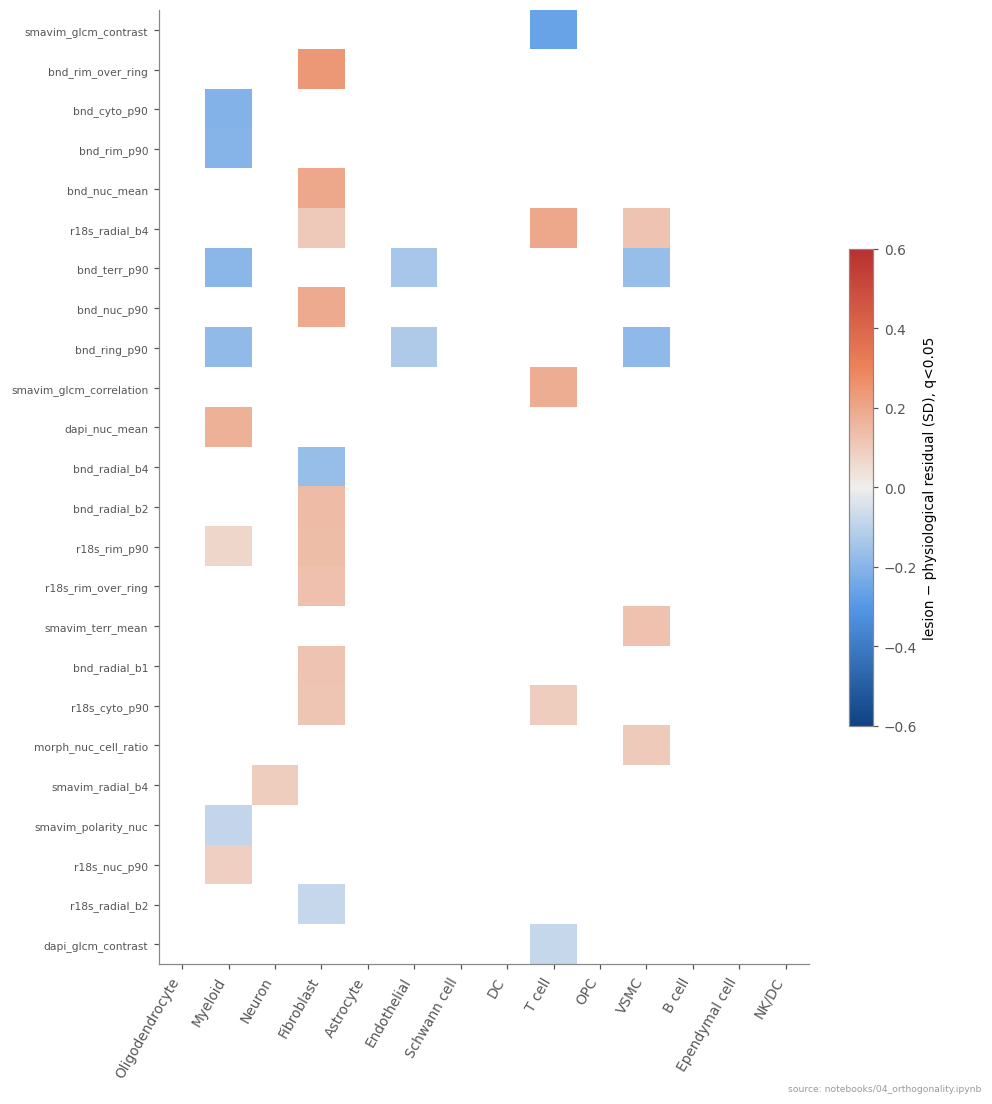

In [12]:
piv = lt.assign(v=np.where(lt.q < 0.05, lt.median_diff, np.nan)).pivot(index="feature", columns="cell_type", values="v")
piv = piv.reindex(columns=TYPES).dropna(how="all")
piv = piv.loc[piv.abs().max(1).sort_values(ascending=False).index[:40]]
fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(piv.values, cmap=plotting.DIV, vmin=-0.6, vmax=0.6, aspect="auto")
ax.set_yticks(range(len(piv)), piv.index, fontsize=7); ax.set_xticks(range(piv.shape[1]), piv.columns, rotation=60, ha="right")
fig.colorbar(im, ax=ax, label="lesion − physiological residual (SD), q<0.05", shrink=0.5)
fig.tight_layout()
plotting.save_fig(fig, "residual_lesion_shift_top40", OUT, SRC)

## 4b. Does adding image features improve lesion-niche classification beyond the transcriptome?
Within each type, lesion vs physiological cells; L2 logistic regression; GroupKFold by animal; inputs
(i) covariates + 50 transcriptome PCs, (ii) + image features. Note lesion niches were defined from transcriptomic
neighbourhoods, so the transcriptome has a head start by construction.

In [13]:
cls = []
for t, r in results.items():
    idx = r["residuals"].index
    d = f.loc[idx]
    keep = (d.lesion | d.phys).values
    if keep.sum() < 300 or d.lesion[keep].mean() < 0.05 or d.lesion[keep].mean() > 0.95:
        continue
    d = d[keep]
    y = d.lesion.values
    C = orth.covariates(d, True)
    Xln = orth.lognorm(adata[d.index].X)
    I = orth.rank_int(d[r["r2"].index]).values
    pred = {k: np.zeros(len(d)) for k in ("tx", "tx+img", "img")}
    for tr, te in GroupKFold(5).split(C, groups=d.sample_name.astype(str).values):
        pca = PCA(50, svd_solver="covariance_eigh", random_state=0).fit(Xln[tr])
        P = pca.transform(Xln)
        P = P / P[tr].std(0)
        for k, Z in (("tx", np.c_[C, P]), ("tx+img", np.c_[C, P, I]), ("img", np.c_[C, I])):
            m = LogisticRegression(C=0.1, max_iter=2000).fit(Z[tr], y[tr])
            pred[k][te] = m.predict_proba(Z[te])[:, 1]
    cls.append(dict(cell_type=t, n=len(d), lesion_frac=y.mean(), **{f"AUROC {k}": roc_auc_score(y, v) for k, v in pred.items()}))
cls = pd.DataFrame(cls).set_index("cell_type")
cls["ΔAUROC (img | tx)"] = cls["AUROC tx+img"] - cls["AUROC tx"]
cls.to_csv(OUT / "lesion_classification.csv")
cls.round(3)

,n,lesion_frac,AUROC tx,AUROC tx+img,AUROC img,ΔAUROC (img | tx)
cell_type,,,,,,
Oligodendrocyte,29895,0.605,0.928,0.929,0.650,0.001
Myeloid,29860,0.942,0.932,0.929,0.670,-0.003
Neuron,29988,0.290,0.846,0.850,0.471,0.004
Fibroblast,29183,0.916,0.884,0.898,0.716,0.015
Astrocyte,29816,0.603,0.947,0.947,0.757,-0.000
Endothelial,27406,0.645,0.937,0.938,0.747,0.001
Schwann cell,20610,0.367,0.936,0.940,0.769,0.004
OPC,14183,0.680,0.955,0.958,0.822,0.003
VSMC,8375,0.791,0.794,0.807,0.650,0.013


## 4c. Residual clusters
Leiden on the PCA of residuals (per type). For each cluster: share in lesion vs physiological niche (per animal),
median distance to lesion, defining image features (mean residual z) and top marker genes (to see whether the
cluster is transcriptionally distinct after all, i.e. a non-linear transcriptome effect).

In [14]:
clus_rows, clus_feats, clus_genes = [], {}, {}
for t, r in results.items():
    res = r["residuals"]
    a_ = ad.AnnData(res.values.astype(np.float32), obs=f.loc[res.index, ["sample_name", "lesion", "phys",
                                                                         "lesion_dist_um", "section_id"]])
    sc.pp.pca(a_, n_comps=min(15, res.shape[1] - 1))
    sc.pp.neighbors(a_, n_neighbors=15)
    sc.tl.leiden(a_, resolution=0.3, flavor="igraph", n_iterations=2, key_added="rc")
    lab = a_.obs.rc.astype(str)
    clus_feats[t] = res.groupby(lab.values).mean()
    for k in sorted(lab.unique(), key=int):
        mk = (lab == k).values
        if mk.sum() < 100:
            continue
        per = a_.obs.assign(k=mk).groupby("sample_name", observed=True).apply(
            lambda g: pd.Series({"L": g.k[g.lesion].mean() if g.lesion.sum() >= 20 else np.nan,
                                 "P": g.k[g.phys].mean() if g.phys.sum() >= 20 else np.nan}), include_groups=False).dropna()
        p = wilcoxon(per.L - per.P).pvalue if len(per) >= 5 else np.nan
        top = clus_feats[t].loc[k].sort_values(key=abs, ascending=False).head(4)
        clus_rows.append(dict(cell_type=t, cluster=k, n=int(mk.sum()), frac=mk.mean(),
                              lesion_minus_phys=(per.L - per.P).median() if len(per) else np.nan, p=p,
                              lesion_dist_median=np.nanmedian(a_.obs.lesion_dist_um[mk]),
                              type_lesion_dist_median=np.nanmedian(a_.obs.lesion_dist_um),
                              top_features=", ".join(f"{i} {v:+.2f}" for i, v in top.items())))
    ag = adata[res.index].copy()
    sc.pp.normalize_total(ag, target_sum=100); sc.pp.log1p(ag)
    ag.obs["rc"] = lab.values
    big = lab.value_counts()
    ag = ag[ag.obs.rc.isin(big[big >= 100].index)].copy()
    if ag.obs.rc.nunique() > 1:
        sc.tl.rank_genes_groups(ag, "rc", method="wilcoxon", n_genes=8)
        clus_genes[t] = sc.get.rank_genes_groups_df(ag, None)
ct = pd.DataFrame(clus_rows)
ct["q"] = bh(ct.p.fillna(1))
ct.to_csv(OUT / "residual_clusters.csv", index=False)
pd.concat(clus_genes, names=["cell_type"]).to_csv(OUT / "residual_cluster_markers.csv")
ct.sort_values("q").round(3).head(30)

/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,cell_type,cluster,n,frac,lesion_minus_phys,p,lesion_dist_median,type_lesion_dist_median,top_features,q
3,Fibroblast,0,13434,0.448,-0.031,0.048,0.000,0.000,"bnd_ring_mean -0.52, smavim_ring_mean -0.52, b...",0.46
4,Fibroblast,1,16566,0.552,0.031,0.048,0.000,0.000,"bnd_ring_mean +0.50, smavim_ring_mean +0.49, b...",0.46
0,Oligodendrocyte,0,30000,1.000,0.000,NaN,0.000,0.000,"smavim_glcm_entropy -0.04, bnd_rim_mean +0.04,...",1.00
16,Ependymal cell,0,2490,0.828,-0.013,NaN,65.095,63.708,"smavim_glcm_entropy +0.24, smavim_glcm_homogen...",1.00
15,B cell,0,4548,1.000,NaN,NaN,0.000,0.000,"smavim_nuc_mean +0.09, dapi_radial_b4 +0.09, d...",1.00
14,VSMC,0,9328,1.000,0.000,NaN,0.000,0.000,"bnd_glcm_contrast -0.06, bnd_glcm_homogeneity ...",1.00
13,OPC,0,14242,1.000,0.000,NaN,0.000,0.000,"bnd_glcm_correlation +0.05, bnd_glcm_contrast ...",1.00
12,T cell,0,15921,1.000,0.000,1.000,0.000,0.000,"smavim_nuc_mean +0.13, bnd_rim_mean +0.12, bnd...",1.00
11,DC,1,8308,0.493,0.100,1.000,0.000,0.000,"smavim_nuc_p90 -0.45, smavim_glcm_asm +0.44, s...",1.00
10,DC,0,8558,0.507,-0.100,1.000,0.000,0.000,"smavim_nuc_mean +0.52, bnd_nuc_p90 +0.47, bnd_...",1.00


Marker genes of residual clusters with a lesion association (q < 0.05) — large log-fold changes here mean the
"unexplained" image signal still tracks a transcriptional state the linear model missed.

In [15]:
for _, row in ct[ct.q < 0.05].sort_values("q").head(12).iterrows():
    g = clus_genes.get(row.cell_type)
    if g is None:
        continue
    gg = g[g.group == row.cluster].head(6)
    print(f"{row.cell_type} c{row.cluster} (n={row.n}, lesion−phys {row.lesion_minus_phys:+.3f}): "
          + ", ".join(f"{a} ({b:.1f})" for a, b in zip(gg.names, gg.logfoldchanges)))